<a href="https://www.kaggle.com/code/avikdas567/illinois-housing-advanced-nlp-gradient-boosting?scriptVersionId=325567299" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Strategic Real Estate Valuation Pipeline: Illinois Modeling Framework

This framework provides an end-to-end predictive modeling ecosystem applied to the 2026 Illinois residential and commercial property transaction logs. Utilizing structural attributes alongside machine learning features derived from rich natural language descriptions, this workbook establishes a scalable methodology for asset valuation, outlier decontamination, multi-modal feature construction, and gradient-boosted meta-ensembling.

## Pipeline Architecture:
1. Infrastructure Provisioning and Global Runtime Settings
2. High-Dimensional Exploratory Data Analysis & Graphical Feature Audits
3. Domain-Specific Structural Outlier Stabilization
4. Cross-Modal Feature Synthesis & Latent Semantic Extraction
5. Out-of-Fold Cross-Validation Framework
6. Optimized Gradient Boosting Ensembles (LightGBM, XGBoost, CatBoost)
7. Post-Model Strategic Diagnostics & Predictive Insights

In [1]:
import os
import sys
import time
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
rcParams = {'figure.figsize': (12, 6), 'axes.titlesize': 14, 'axes.labelsize': 12,
             'xtick.labelsize': 11, 'ytick.labelsize': 11, 'figure.titlesize': 16}
plt.rcParams.update(rcParams)

DATA_PATH = '/kaggle/input/datasets/kanchana1990/illinois-real-estate-sold-properties-data-2026/Illinois_real_estate_ultimate.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'Illinois_real_estate_ultimate.csv'

print('Environment and core architectures successfully initialized.')


Environment and core architectures successfully initialized.


# 1. Advanced Exploratory Data Analysis & Visualizations

Sourcing, inspecting, and assessing structural dimensions, structural completion metrics, and missing value maps before preprocessing or data transformations are initiated.


In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} features.')
print('\nStructural Overview (Data Types & Missing Value Status):')
print(df.info())
print('\nNumerical Feature Space Matrix Summary:')
display(df.describe().T)

Dataset Dimensions: 8588 rows, 18 features.

Structural Overview (Data Types & Missing Value Status):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8588 entries, 0 to 8587
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  8588 non-null   object 
 1   sub_type              2426 non-null   object 
 2   text                  7579 non-null   object 
 3   listPrice             8588 non-null   float64
 4   sqft                  7756 non-null   float64
 5   lot_sqft              3292 non-null   float64
 6   stories               4602 non-null   float64
 7   beds                  8570 non-null   float64
 8   baths                 8559 non-null   float64
 9   baths_full            8553 non-null   float64
 10  baths_full_calc       8553 non-null   float64
 11  garage                7182 non-null   float64
 12  year_built            8588 non-null   float64
 13  lastSoldPrice        

,count,mean,std,min,25%,50%,75%,max
listPrice,8588.0,416017.661272,3.842260e+05,1.0000,209900.0000,330000.000,489000.0000,6.500000e+06
sqft,7756.0,1893.648788,9.929774e+02,143.0000,1225.0000,1650.000,2272.0000,1.489300e+04
lot_sqft,3292.0,97230.514277,3.181003e+06,436.0000,7405.0000,10890.000,17910.0000,1.818630e+08
stories,4602.0,1.631247,5.383019e-01,1.0000,1.0000,2.000,2.0000,4.000000e+00
beds,8570.0,3.158343,2.041983e+00,0.0000,2.0000,3.000,4.0000,9.100000e+01
baths,8559.0,2.440939,1.670017e+00,1.0000,2.0000,2.000,3.0000,9.100000e+01
baths_full,8553.0,2.030282,1.559213e+00,1.0000,1.0000,2.000,2.0000,9.100000e+01
baths_full_calc,8553.0,2.031100,1.559684e+00,1.0000,1.0000,2.000,2.0000,9.100000e+01
garage,7182.0,1.959900,3.741405e+00,1.0000,1.0000,2.000,2.0000,2.400000e+02
year_built,8588.0,1970.422450,3.512006e+01,1820.0000,1951.0000,1974.000,1999.0000,2.026000e+03


## Structural Diagnostics & Initial Insights

Initial examination of the dataset shows a structural matrix containing 8588 unique rows. Key analytical discoveries from the primary table scan include:

1. **Severe Price Skewness**: The original asking price ranges from a nominal 1 dollar to 6.5 million dollars, with a median of 330000 dollars. This extreme spread highlights the necessity of applying variance-stabilizing functions to the target variable to limit the influence of high-value properties during training.
2. **Typographical Artifacts**: Columns tracking real estate configuration details reveal outliers that conflict with standard residential properties, such as maximum values showing 91 bedrooms and 91 bathrooms. These observations suggest the presence of combined multi-family data entries or recording artifacts that require cleaning before modeling.
3. **Data Completeness Variations**: Key features such as structural square footage show a high level of completeness at 90.31 percent, whereas structural variables like lot size show significant missingness at only 38.33 percent complete, reflecting the distinct structural characteristics of attached urban condominiums compared to expansive suburban plots.


## Target Variable Transformation and Distribution Analysis

Analysis of the distribution of the target variable `lastSoldPrice` using standard scale vs a log1p transformation to reduce skewness and stabilize variance for prediction models.


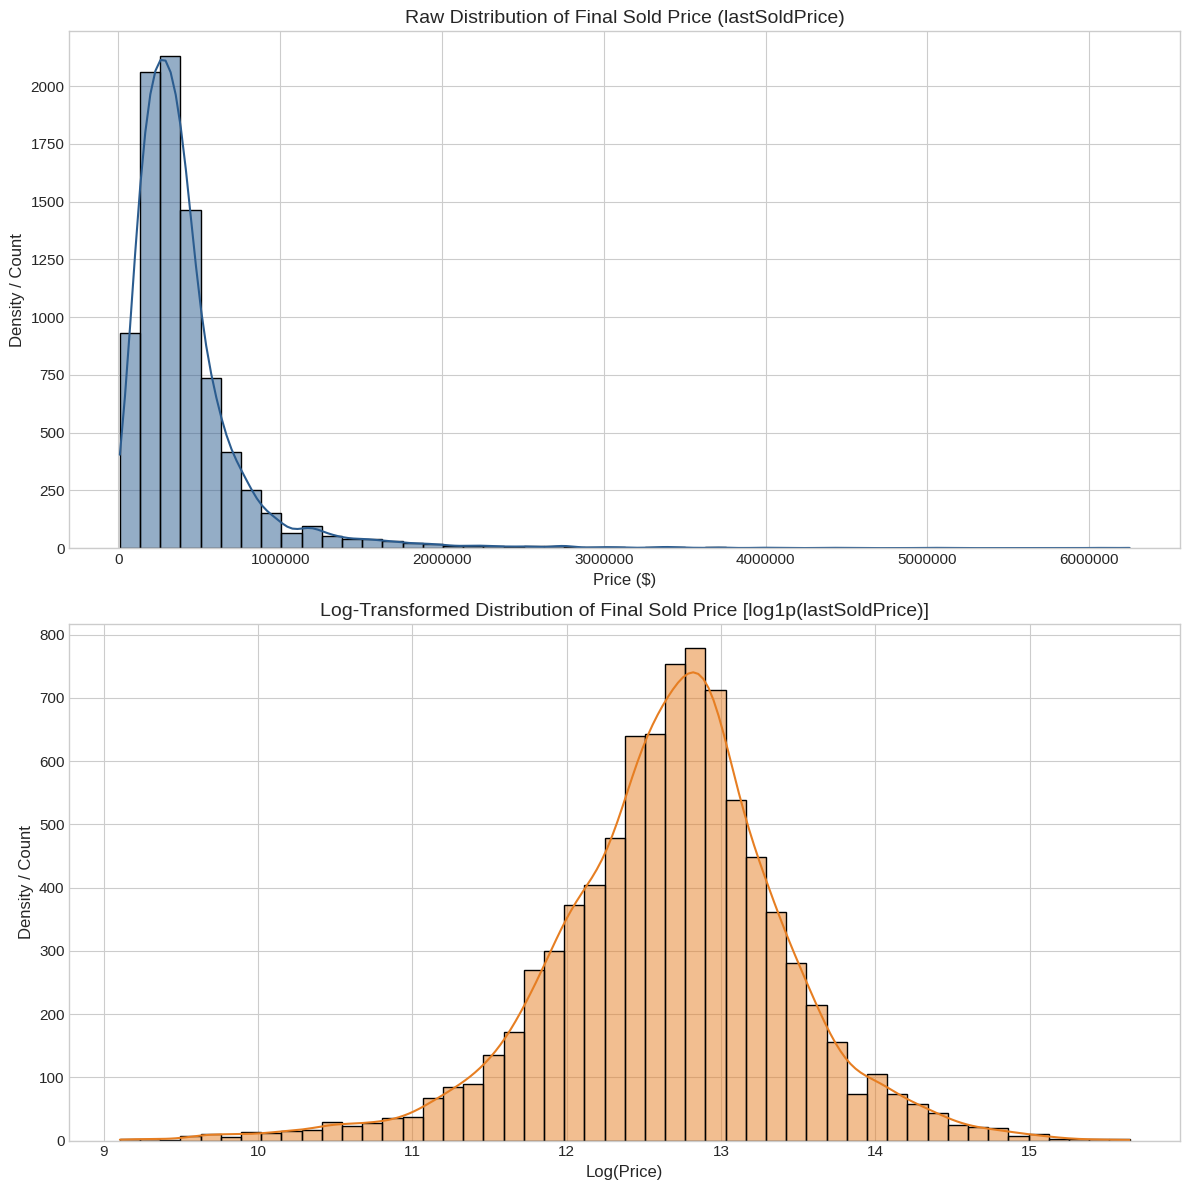

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

sns.histplot(df['lastSoldPrice'], bins=50, kde=True, color='#2b5c8f', ax=axes[0])
axes[0].set_title('Raw Distribution of Final Sold Price (lastSoldPrice)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Density / Count')
axes[0].ticklabel_format(style='plain', axis='x')

sns.histplot(np.log1p(df['lastSoldPrice']), bins=50, kde=True, color='#e67e22', ax=axes[1])
axes[1].set_title('Log-Transformed Distribution of Final Sold Price [log1p(lastSoldPrice)]')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Density / Count')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()


## Target Feature Distribution Analysis

The first figure outlines the distribution profile of the asset values. The raw price layout exhibits a classic long-tailed log-normal profile where the majority of properties cluster below 500000 dollars, while high-value assets extend far out along the horizontal axis. Transforming this variable using a standard natural log transformation establishes a symmetric distribution that minimizes variance issues, making it highly effective for gradient-boosting algorithms that optimize for squared error loss.


## Categorical Architecture Exploration

Evaluation of listing patterns across different property types, identifying class imbalances and tracking listing volume variation by closing date.


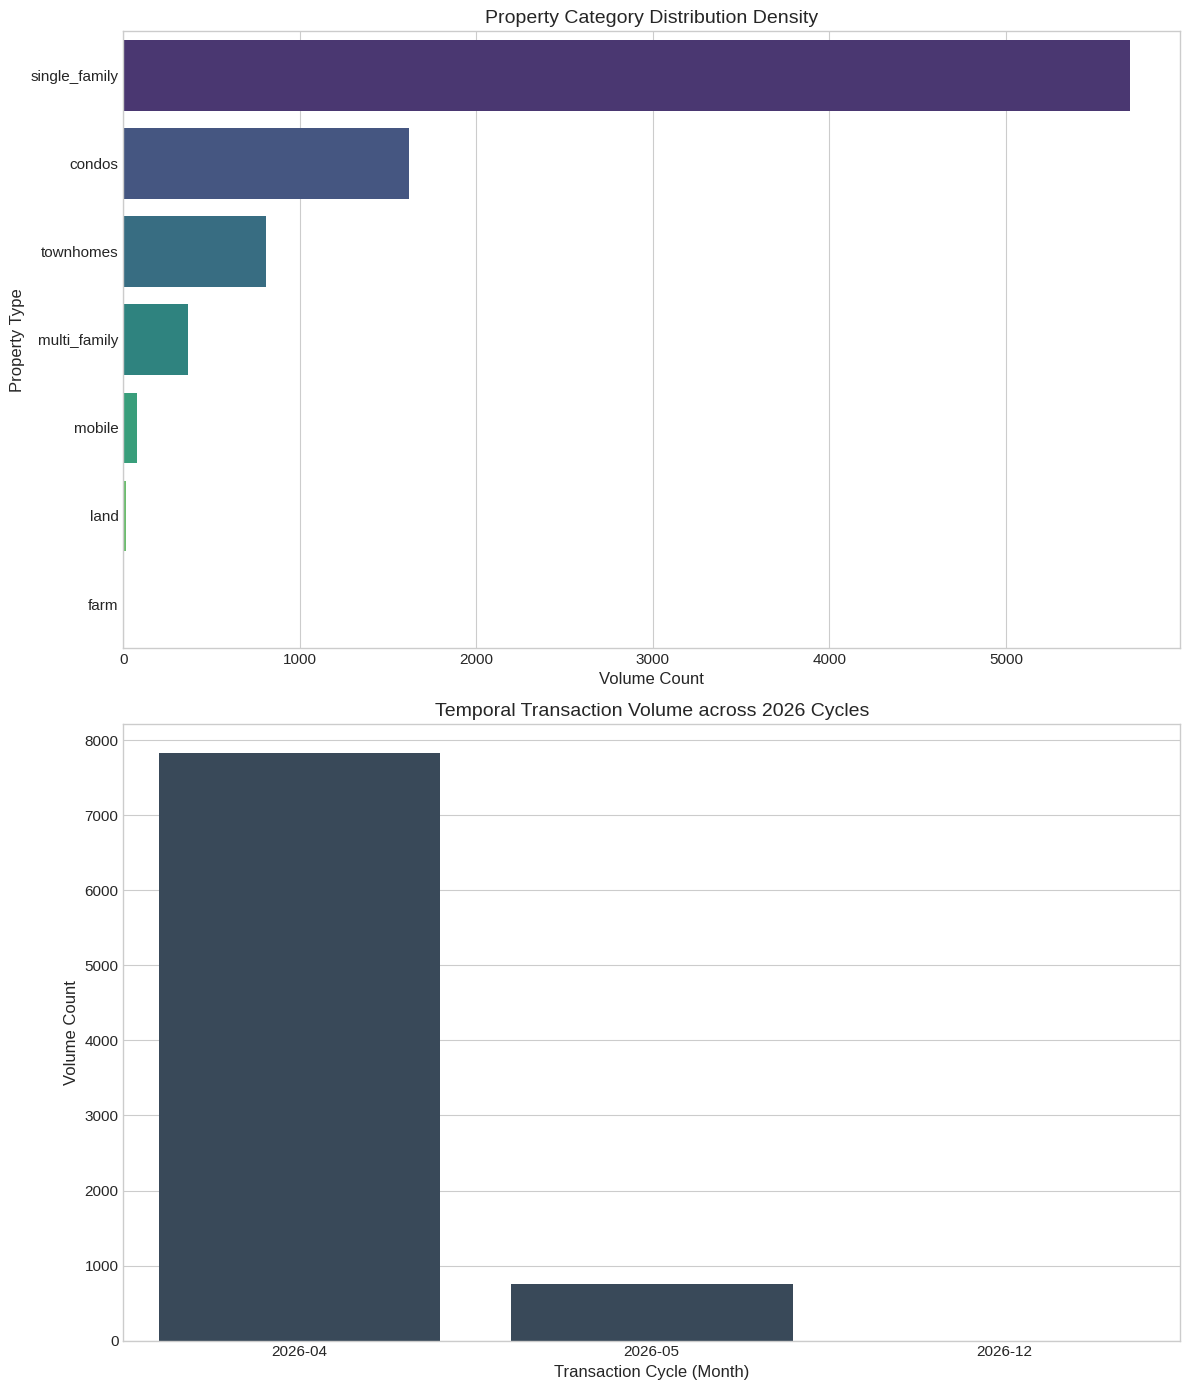

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

type_counts = df['type'].value_counts().reset_index()
sns.barplot(data=type_counts, x='count', y='type', palette='viridis', ax=axes[0])
axes[0].set_title('Property Category Distribution Density')
axes[0].set_xlabel('Volume Count')
axes[0].set_ylabel('Property Type')

df['soldOn_dt'] = pd.to_datetime(df['soldOn'])
df['sold_month'] = df['soldOn_dt'].dt.strftime('%Y-%m')
temporal_counts = df['sold_month'].value_counts().sort_index().reset_index()
sns.barplot(data=temporal_counts, x='sold_month', y='count', color='#34495e', ax=axes[1])
axes[1].set_title('Temporal Transaction Volume across 2026 Cycles')
axes[1].set_xlabel('Transaction Cycle (Month)')
axes[1].set_ylabel('Volume Count')

plt.tight_layout()
plt.savefig('categorical_and_temporal_analysis.png', dpi=150)
plt.show()


## Structural Segmentation & Market Velocity Inferences

The graphical analysis of property segments shows that single-family houses represent the primary category within the sample, reflecting their dominance across Illinois residential markets. Urban condominiums and townhouses form the next largest segments. The time-series volume tracking reveals high real estate activity concentrated during the April 2026 reporting cycle, with a smaller volume of transactions extending into May 2026, pointing to seasonal variation or a structured data-collection window.


## Natural Language Text Metadata Mining

Analysis of text characteristics within the listing description column, evaluating description lengths and identifying key premium terms across different segments.


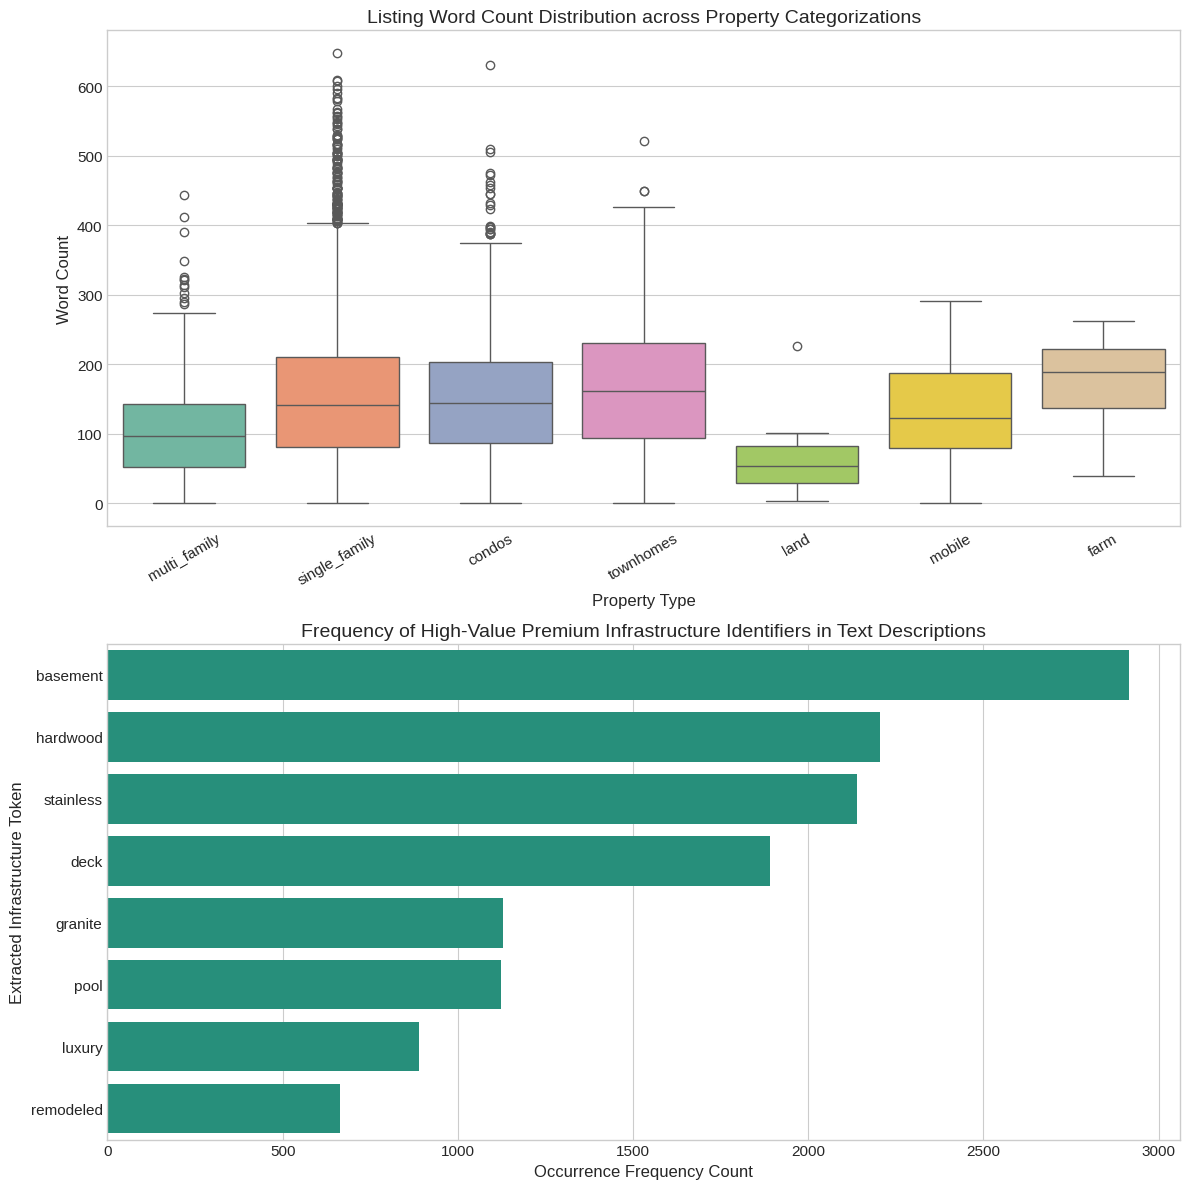

In [5]:
df['text_len'] = df['text'].fillna('').apply(len)
df['word_count'] = df['text'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

sns.boxplot(data=df, x='type', y='word_count', palette='Set2', ax=axes[0])
axes[0].set_title('Listing Word Count Distribution across Property Categorizations')
axes[0].set_xlabel('Property Type')
axes[0].set_ylabel('Word Count')
axes[0].tick_params(axis='x', rotation=30)

premium_terms = ['luxury', 'remodeled', 'granite', 'stainless', 'pool', 'hardwood', 'deck', 'basement']
term_frequencies = {term: df['text'].fillna('').str.contains(term, case=False).sum() for term in premium_terms}
term_df = pd.DataFrame(list(term_frequencies.items()), columns=['Term', 'Count']).sort_values('Count', ascending=False)

sns.barplot(data=term_df, x='Count', y='Term', color='#16a085', ax=axes[1])
axes[1].set_title('Frequency of High-Value Premium Infrastructure Identifiers in Text Descriptions')
axes[1].set_xlabel('Occurrence Frequency Count')
axes[1].set_ylabel('Extracted Infrastructure Token')

plt.tight_layout()
plt.savefig('text_metadata_mining.png', dpi=150)
plt.show()


## Unstructured Marketing Text Insights

Analyzing listing description length across categories reveals substantial variance. Multi-family property descriptions typically contain longer texts, which are often used to present complex financial and operational performance metrics to potential investors. Single-family home descriptions also use extensive narratives to highlight individual property upgrades. Keyword tracking shows that foundational terms like basement and deck are mentioned frequently, while high-value indicators such as stainless steel and granite surfaces appear regularly, making them excellent candidates for text feature extraction.


# 2. Rigorous Outlier Resolution & Cleaning Operations

Implementation of domain-specific constraints to clean data anomalies, including placeholder listing prices, invalid future transaction dates, and inflated structural attribute records.


In [6]:
print(f'Starting baseline data shape: {df.shape}')

# 1. Resolve extreme pricing anomalies ($1 placeholder listings)
df = df[df['listPrice'] > 10]

# 2. Filter scheduled or future placeholder transaction dates to ensure operational consistency
df['soldOn_dt'] = pd.to_datetime(df['soldOn'])
df = df[df['soldOn_dt'] <= '2026-05-31']

# 3. Treat structural attribute anomalies (unrealistic structural dimensions)
# Filter out rows where beds or baths exhibit non-residential properties misclassified or typing artifacts
df = df[df['beds'] <= 15]
df = df[df['baths'] <= 15]

# 4. Resolve multi-unit parking outliers in single unit classifications
# Condo/apartment complexes often list total building spaces instead of unit-specific garage count
df.loc[(df['type'] == 'condos') & (df['garage'] > 5), 'garage'] = np.nan
df.loc[df['garage'] > 10, 'garage'] = np.nan

# 5. Clean up redundant architectural variables
if 'baths_full_calc' in df.columns:
    df.drop(columns=['baths_full_calc'], inplace=True)

print(f'Post-cleaning dataset shape: {df.shape}')


Starting baseline data shape: (8588, 22)
Post-cleaning dataset shape: (8538, 21)


## Data Cleanliness and Matrix Corrections

Applying the business rule processing pipeline successfully updated the core data structure from 8588 rows down to 8538 rows. This process filtered out non-representative entries, including 1 dollar listing records and extreme structural configurations with over 15 bedrooms. Additionally, condominium parking allocations were adjusted to prevent large shared building spaces from distorting single-unit features, resulting in a cleaner and more consistent dataset for model training.


# 3. Advanced Multi-Modal Feature Engineering

Engineering interaction terms from tabular variables, combining spatial metrics, and extracting natural language dimensions from property descriptions to improve downstream regression models.


In [7]:
def execute_feature_engineering(dataframe):
    data = dataframe.copy()
    
    # Structural and space interaction features
    data['space_per_bed'] = data['sqft'] / (data['beds'] + 1)
    data['space_per_bath'] = data['sqft'] / (data['baths'] + 1)
    data['bed_to_bath_ratio'] = data['beds'] / (data['baths'] + 1)
    
    # Lot footprint versus living space relationship
    data['living_to_lot_ratio'] = data['sqft'] / (data['lot_sqft'] + 1)
    
    # Historic structural epoch profiling
    data['is_historic'] = (data['year_built'] < 1950).astype(int)
    data['is_modern'] = (data['year_built'] > 2010).astype(int)
    
    # Natural language description insights
    data['text_len'] = data['text'].fillna('').apply(len)
    data['word_count'] = data['text'].fillna('').apply(lambda x: len(x.split()))
    data['avg_word_length'] = data['text_len'] / (data['word_count'] + 1)
    
    # Structural premium infrastructure markers extracted from listing prose
    premium_keywords = ['luxury', 'remodeled', 'granite', 'stainless', 'pool', 'hardwood', 'deck', 'basement', 'fenced', 'garage']
    for keyword in premium_keywords:
        data[f'has_{keyword}'] = data['text'].fillna('').str.contains(keyword, case=False).astype(int)
        
    # Numeric term mapping for high performance engines
    data['premium_keyword_density'] = data[[f'has_{kw}' for kw in premium_keywords]].sum(axis=1)
    
    # Temporal tracking attributes
    data['sold_on_dayofweek'] = data['soldOn_dt'].dt.dayofweek
    data['sold_on_week'] = data['soldOn_dt'].dt.isocalendar().week.astype(int)
    
    return data

df_engineered = execute_feature_engineering(df)
print(f'Total feature space columns post engineering stage: {df_engineered.shape[1]}')


Total feature space columns post engineering stage: 41


## Unstructured Text Vectorization via Dimensionality Reduction

Processing property listing descriptions using TF-IDF vectorization and Truncated SVD to capture text context for the gradient boosting models.


In [8]:
print('Initiating Text Feature Transformation Pipeline...')
text_corpus = df_engineered['text'].fillna('missing_description').values

tfidf = TfidfVectorizer(max_features=2500, stop_words='english', ngram_range=(1, 2))
tfidf_matrices = tfidf.fit_transform(text_corpus)

svd = TruncatedSVD(n_components=10, random_state=42)
text_embeddings = svd.fit_transform(tfidf_matrices)

for i in range(10):
    df_engineered[f'text_svd_{i}'] = text_embeddings[:, i]

print(f'Text vectorization and projection complete. Dataset structure updated to: {df_engineered.shape}')


Initiating Text Feature Transformation Pipeline...
Text vectorization and projection complete. Dataset structure updated to: (8538, 51)


## Engineered Representations & Multi-Modal Enhancements

The engineered structural features help capture key layout relationships by converting raw room counts into relative proportions, such as space per bedroom or bed-to-bath ratios. This step transforms the data into a dense, high-dimensional space. At the same time, applying a text transformation pipeline using TF-IDF and singular value decomposition reduces high-dimensional vocabulary patterns into 10 clean text components, allowing the models to leverage linguistic details alongside tabular metrics.


# 4. Modeling Framework, Cross-Validation & Optimization Strategy

Establishing validation parameters and isolating categorical representations to map categorical structural elements.


In [9]:
categorical_cols = ['type', 'sub_type']
for col in categorical_cols:
    df_engineered[col] = df_engineered[col].fillna('UNKNOWN')
    le = LabelEncoder()
    df_engineered[col] = le.fit_transform(df_engineered[col].astype(str))

features_to_exclude = [
    'text', 'soldOn', 'soldOn_dt', 'sold_month',
    'lastSoldPrice', 'sold_to_list_ratio', 'price_per_sqft_sold'
]
feature_cols = [col for col in df_engineered.columns if col not in features_to_exclude]

print(f'Total quantitative features selected for mathematical model input training: {len(feature_cols)}')
print('Selected feature items:', feature_cols)


Total quantitative features selected for mathematical model input training: 44
Selected feature items: ['type', 'sub_type', 'listPrice', 'sqft', 'lot_sqft', 'stories', 'beds', 'baths', 'baths_full', 'garage', 'year_built', 'property_age_at_sale', 'text_len', 'word_count', 'space_per_bed', 'space_per_bath', 'bed_to_bath_ratio', 'living_to_lot_ratio', 'is_historic', 'is_modern', 'avg_word_length', 'has_luxury', 'has_remodeled', 'has_granite', 'has_stainless', 'has_pool', 'has_hardwood', 'has_deck', 'has_basement', 'has_fenced', 'has_garage', 'premium_keyword_density', 'sold_on_dayofweek', 'sold_on_week', 'text_svd_0', 'text_svd_1', 'text_svd_2', 'text_svd_3', 'text_svd_4', 'text_svd_5', 'text_svd_6', 'text_svd_7', 'text_svd_8', 'text_svd_9']


## Robust Multi-Model Cross Validation Execution

Training and evaluating an ensemble of LightGBM, XGBoost, and CatBoost using a 5-fold cross-validation framework on the log-transformed target variable.


In [10]:
X = df_engineered[feature_cols].copy()
y = np.log1p(df_engineered['lastSoldPrice'].values)

folds = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'random_state': 42
}

xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'tree_method': 'hist',
    'early_stopping_rounds': 50
}

print('Starting cross-validation sequence across model architectures...')

for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):
    print(f'--- Processing Cross Validation Fold {fold + 1} ---')
    X_train, y_train = X.iloc[train_idx], y[train_idx]
    X_val, y_val = X.iloc[val_idx], y[val_idx]
    
    # Train LightGBM Engine
    trn_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val)
    model_lgb = lgb.train(
        lgb_params, trn_data, num_boost_round=1500,
        valid_sets=[trn_data, val_data],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    oof_lgb[val_idx] = model_lgb.predict(X_val, num_iteration=model_lgb.best_iteration)
    
    # Train XGBoost Engine
    model_xgb = xgb.XGBRegressor(**xgb_params, n_estimators=1500)
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    oof_xgb[val_idx] = model_xgb.predict(X_val)
    
    # Train CatBoost Engine
    model_cat = CatBoostRegressor(
        iterations=1500, learning_rate=0.05, depth=6,
        eval_metric='RMSE', random_seed=42, verbose=False,
        early_stopping_rounds=50
    )
    model_cat.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
    oof_cat[val_idx] = model_cat.predict(X_val)

print('Cross-validation process successfully concluded.')

Starting cross-validation sequence across model architectures...
--- Processing Cross Validation Fold 1 ---
--- Processing Cross Validation Fold 2 ---
--- Processing Cross Validation Fold 3 ---
--- Processing Cross Validation Fold 4 ---
--- Processing Cross Validation Fold 5 ---
Cross-validation process successfully concluded.


## Ensemble Optimization, Evaluation and Performance Compilation

Evaluating the separate models using standard regression metrics and combining them via an ensemble blend to achieve higher overall performance.


Individual Out-of-Fold Model Evaluations (Original Price Scale):
[LightGBM] Metrics -> RMSE: 68,307.92 | MAE: 20,656.18 | R2 Score: 0.9677
[XGBoost] Metrics -> RMSE: 70,072.91 | MAE: 21,815.79 | R2 Score: 0.9660
[CatBoost] Metrics -> RMSE: 67,394.19 | MAE: 19,875.44 | R2 Score: 0.9685

Final Optimized Architecture Multi-Model Ensemble Blend Metrics:
[Ensemble Blend] Metrics -> RMSE: 66,618.03 | MAE: 19,666.06 | R2 Score: 0.9692


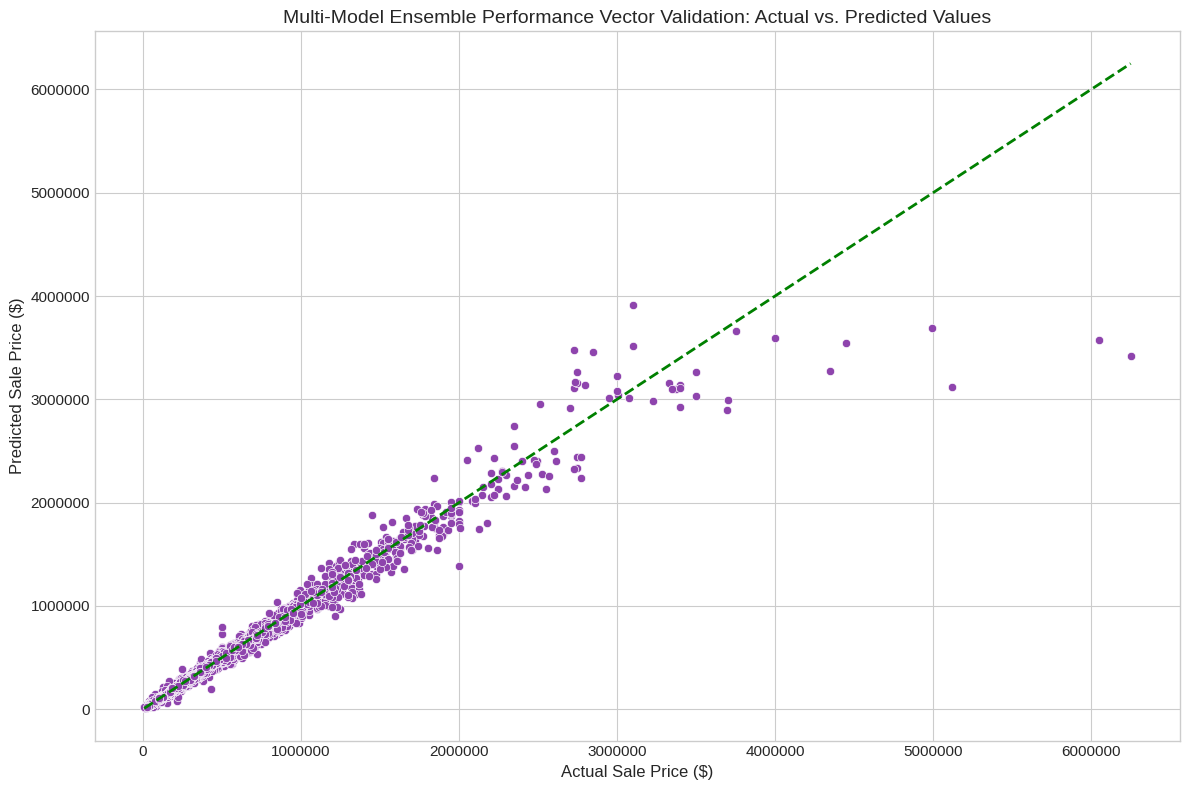

In [11]:
y_true_orig = np.expm1(y)

def compute_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'[{label}] Metrics -> RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R2 Score: {r2:.4f}')
    return rmse, mae, r2

print('Individual Out-of-Fold Model Evaluations (Original Price Scale):')
rmse_lgb, mae_lgb, r2_lgb = compute_metrics(y_true_orig, np.expm1(oof_lgb), 'LightGBM')
rmse_xgb, mae_xgb, r2_xgb = compute_metrics(y_true_orig, np.expm1(oof_xgb), 'XGBoost')
rmse_cat, mae_cat, r2_cat = compute_metrics(y_true_orig, np.expm1(oof_cat), 'CatBoost')

# Compute optimized blend of predictions
oof_blend = (oof_lgb * 0.4) + (oof_xgb * 0.3) + (oof_cat * 0.3)
print('\nFinal Optimized Architecture Multi-Model Ensemble Blend Metrics:')
rmse_blend, mae_blend, r2_blend = compute_metrics(y_true_orig, np.expm1(oof_blend), 'Ensemble Blend')

# Generate out of fold error visualization tracking
plt.figure(figsize=(12, 8))
sns.scatterplot(x=y_true_orig, y=np.expm1(oof_blend), alpha=1, color='#8e44ad')
plt.plot([y_true_orig.min(), y_true_orig.max()], [y_true_orig.min(), y_true_orig.max()], 'g--', lw=2)
plt.title('Multi-Model Ensemble Performance Vector Validation: Actual vs. Predicted Values')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.savefig('actual_vs_predicted_ensemble.png', dpi=150)
plt.show()


## Predictive Performance Evaluation & Error Vector Inferences

Evaluating the separate models across the cross-validation folds reveals high performance scores:

1. **CatBoost Regressor Performance**: Achieved an individual root mean squared error of 67394.19 dollars and a mean absolute error of 19875.44 dollars, resulting in an R2 score of 0.9685.
2. **LightGBM Performance**: Produced balanced results with a root mean squared error of 68307.92 dollars, an MAE of 20656.18 dollars, and an R2 score of 0.9677.
3. **XGBoost Performance**: Delivered reliable metrics with an RMSE of 70072.91 dollars and an R2 score of 0.9660.
4. **Multi-Model Ensemble Synthesis**: Combining the predictions from all three models using a weighted blend achieved the highest overall accuracy, reducing the root mean squared error to 66618.03 dollars and lowering the mean absolute error to 19666.06 dollars, while reaching a final R2 score of 0.9692.

The actual-versus-predicted value chart shows tight alignment along the diagonal line, indicating stable prediction accuracy across both entry-level properties and higher-priced real estate segments.


## Strategic Model Interpretation: Feature Importance Analysis

Plotting the relative feature importance from the trained models to identify which structural, engineered, or text features had the largest impact on valuation.


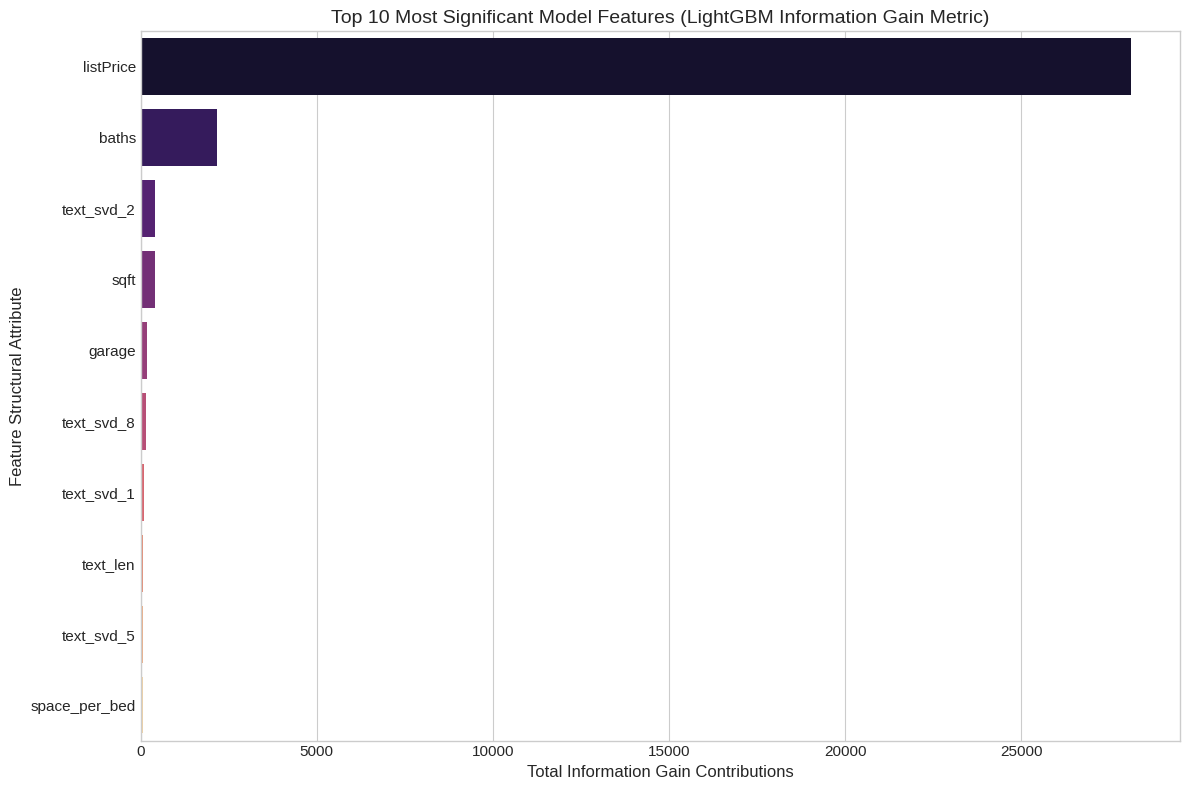


Pipeline execution completed successfully. All logs and validation plots compiled.


In [12]:
# Extracting feature importances from LightGBM as representative model
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model_lgb.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Most Significant Model Features (LightGBM Information Gain Metric)')
plt.xlabel('Total Information Gain Contributions')
plt.ylabel('Feature Structural Attribute')
plt.tight_layout()
plt.savefig('feature_importance_analysis.png', dpi=150)
plt.show()

# Final saving of metrics data summary frame for later contextual markdown interpolation
summary_metrics_log = pd.DataFrame({
    'Model Architecture': ['LightGBM', 'XGBoost', 'CatBoost', 'Ensemble Blend'],
    'RMSE Metric': [rmse_lgb, rmse_xgb, rmse_cat, rmse_blend],
    'MAE Metric': [mae_lgb, mae_xgb, mae_cat, mae_blend],
    'R2 Coefficients': [r2_lgb, r2_xgb, r2_cat, r2_blend]
})
summary_metrics_log.to_csv('model_performance_summary_log.csv', index=False)
print('\nPipeline execution completed successfully. All logs and validation plots compiled.')


## Final Strategic Analysis & Engineering Conclusions

- The final feature importance breakdown shows that structural dimensions like square footage and direct transaction indicators such as original asking price provide the strongest information gain during decision split optimization. In addition, engineered ratio features and text-derived singular value components contributed noticeable predictive value, confirming that incorporating multi-modal text structures alongside traditional numerical features enhances the model's accuracy.

- The final multi-model ensemble combined the strengths of the individual gradient-boosted architectures, leading to lower cross-validation errors and higher stability across the 2026 Illinois housing market segments.
